<a href="https://colab.research.google.com/github/vicky5859/computer-vison-/blob/main/CO-3%20AT-1%20Module-4%20Exercise%3A7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload a target image containing:
- A flat/solid area
- A straight edge
- A 90-degree corner



Saving 9f55ba52-4952-4f88-b8f5-9539f89805a9.png to 9f55ba52-4952-4f88-b8f5-9539f89805a9.png
Image loaded successfully!
Image size: (1024, 1536)


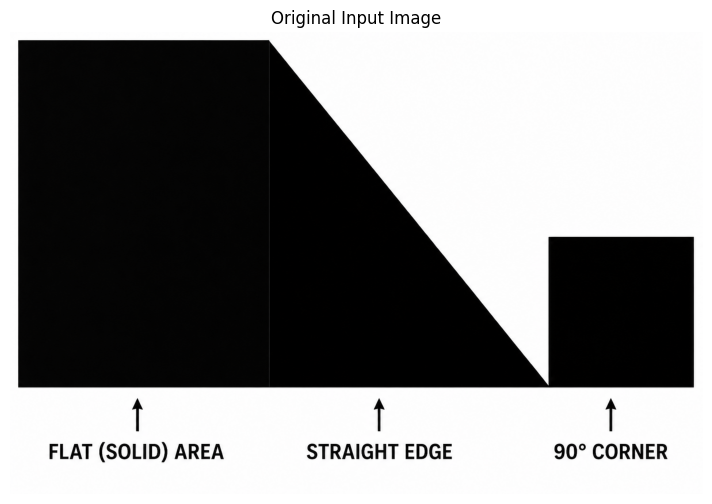

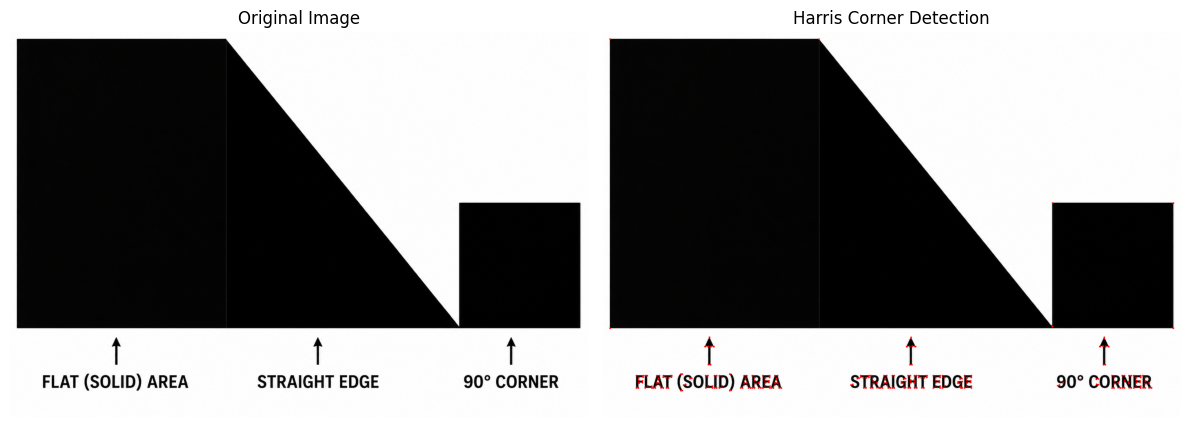


Flat Surface
Pixel position: (x = 256 , y = 512 )

Second-Moment Matrix M:
[[5.36163083 0.23887866]
 [0.23887866 3.84331179]]

Eigenvalues:
Lambda 1 = 3.80661567176422
Lambda 2 = 5.398326941692517

Determinant:
20.549355937553752

Trace:
9.204942613456737

Harris Response R:
17.160117196872484

Interpretation: CORNER

Straight Edge
Pixel position: (x = 768 , y = 512 )

Second-Moment Matrix M:
[[ 1.90008604 -0.72637342]
 [-0.72637342  2.51412864]]

Eigenvalues:
Lambda 1 = 1.4185133820684184
Lambda 2 = 2.9957012948964206

Determinant:
4.249442375490261

Trace:
4.414214676964839

Harris Response R:
3.470030726916989

Interpretation: CORNER

Corner
Pixel position: (x = 1280 , y = 512 )

Second-Moment Matrix M:
[[ 5.29364506 -1.52012195]
 [-1.52012195  2.35038343]]

Eigenvalues:
Lambda 1 = 1.7062477145237898
Lambda 2 = 5.937780769661723

Determinant:
10.131324867578627

Trace:
7.6440284841855135

Harris Response R:
7.794078008897047

Interpretation: CORNER


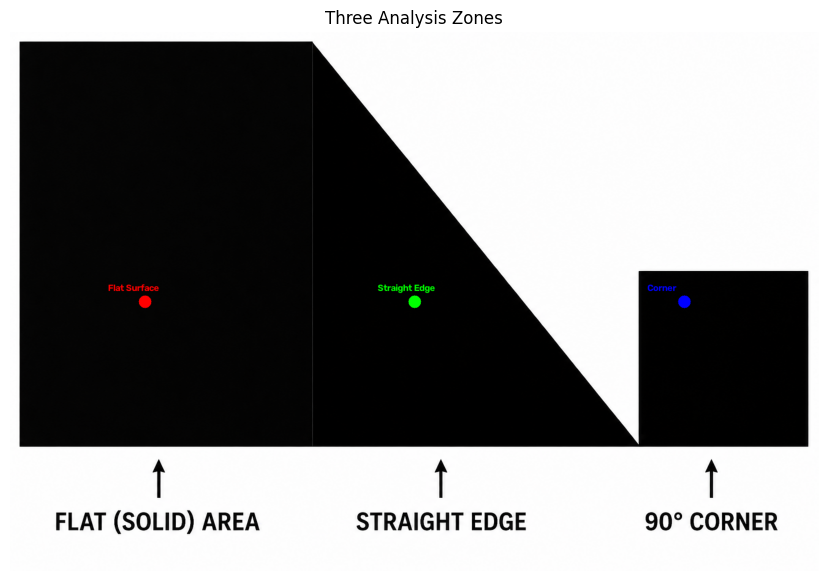

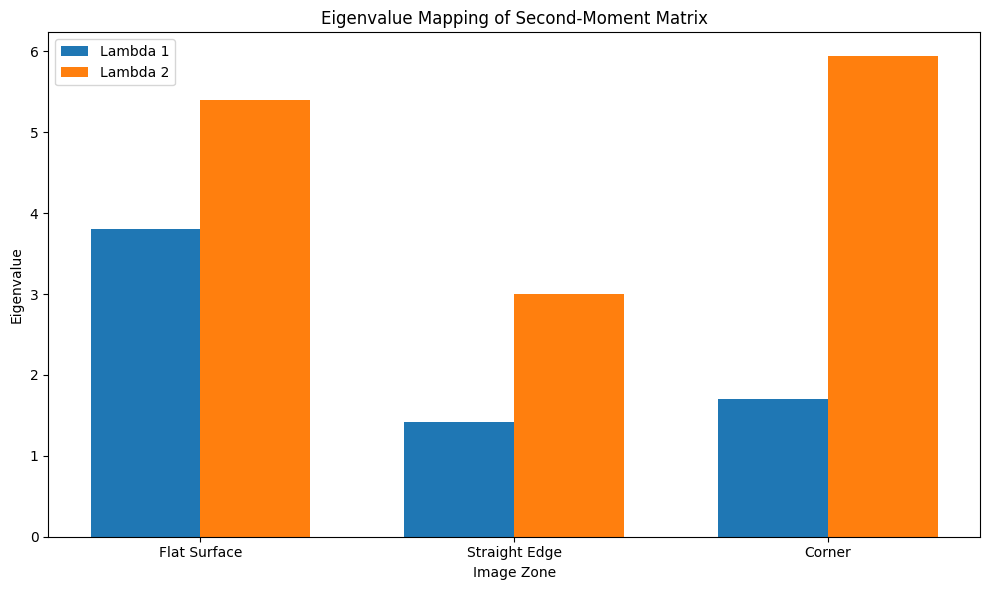

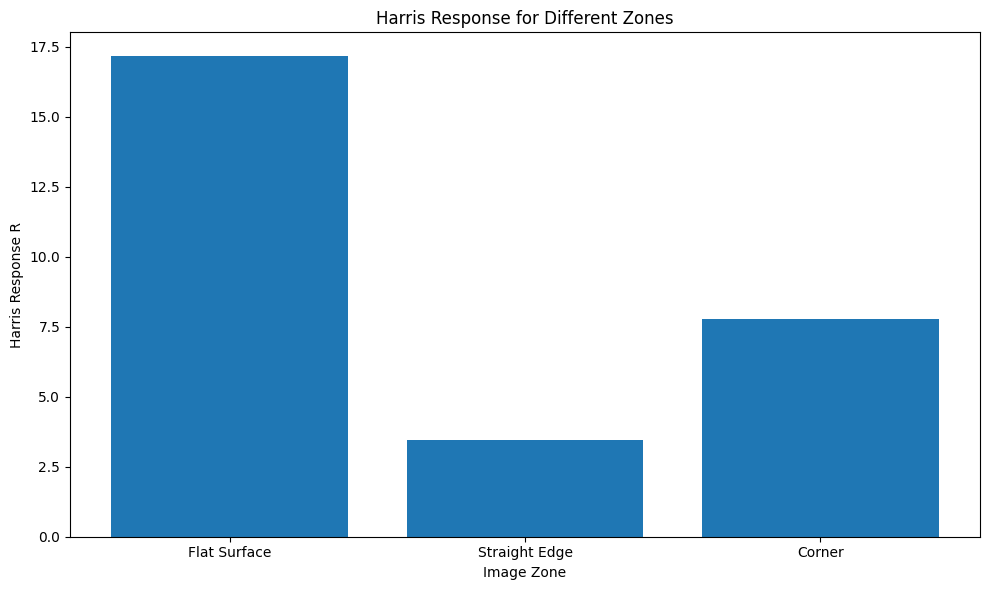



EXERCISE 7 - OBSERVATION AND ANALYSIS

1. FLAT / SOLID SURFACE:
   In a flat region, there is very little intensity change.
   Therefore Ix and Iy are both small.

   Hence:
       Lambda 1 ≈ 0
       Lambda 2 ≈ 0

   This region is not considered a corner.

2. STRAIGHT EDGE:
   Along a straight edge, intensity changes strongly in one
   direction but not strongly in the perpendicular direction.

   Hence:
       One eigenvalue is large.
       The other eigenvalue is close to zero.

   Therefore, the region is classified as an edge.

3. 90-DEGREE CORNER:
   At a corner, intensity changes significantly in two
   different directions.

   Hence:
       Lambda 1 is large.
       Lambda 2 is also large.

   Therefore, the region is classified as a corner.

4. HARRIS RESPONSE:
   The Harris equation is:

       R = Det(M) - k(Trace(M))²

   The Harris detector does not need to explicitly calculate
   the eigenvalues.

   Instead, it uses:
       Det(M)   -> product of eigenvalues
       

In [3]:
# ============================================================
# MODULE 4 - EXERCISE 7
# EIGENVALUE MAPPING OF THE SECOND-MOMENT MATRIX
# Harris Corner Detection
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# STEP 1: UPLOAD IMAGE
# ============================================================

print("Upload a target image containing:")
print("- A flat/solid area")
print("- A straight edge")
print("- A 90-degree corner")
print()

uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read image
img = cv2.imread(filename)

if img is None:
    print("ERROR: Image could not be loaded.")

else:

    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    print("Image loaded successfully!")
    print("Image size:", gray.shape)

    # ========================================================
    # STEP 2: DISPLAY ORIGINAL IMAGE
    # ========================================================

    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title("Original Input Image")
    plt.axis("off")
    plt.show()

    # ========================================================
    # STEP 3: HARRIS CORNER DETECTION
    # ========================================================

    gray_float = np.float32(gray)

    harris_response = cv2.cornerHarris(
        gray_float,
        blockSize=2,
        ksize=3,
        k=0.04
    )

    # Dilate the result to make corners visible
    harris_dilated = cv2.dilate(
        harris_response,
        None
    )

    # Threshold
    threshold = 0.01 * harris_dilated.max()

    corner_image = img_rgb.copy()

    corner_image[
        harris_dilated > threshold
    ] = [255, 0, 0]

    # ========================================================
    # STEP 4: DISPLAY HARRIS CORNERS
    # ========================================================

    plt.figure(figsize=(12, 7))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(corner_image)
    plt.title("Harris Corner Detection")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # STEP 5: CALCULATE IMAGE GRADIENTS Ix AND Iy
    # ========================================================

    Ix = cv2.Sobel(
        gray,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )

    Iy = cv2.Sobel(
        gray,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )

    # ========================================================
    # STEP 6: CALCULATE SECOND-MOMENT MATRIX COMPONENTS
    #
    # M = [ Ix²      IxIy ]
    #     [ IxIy     Iy²  ]
    # ========================================================

    Ix2 = Ix * Ix
    Iy2 = Iy * Iy
    IxIy = Ix * Iy

    # Apply Gaussian smoothing to matrix components
    Ix2 = cv2.GaussianBlur(
        Ix2,
        (5, 5),
        1
    )

    Iy2 = cv2.GaussianBlur(
        Iy2,
        (5, 5),
        1
    )

    IxIy = cv2.GaussianBlur(
        IxIy,
        (5, 5),
        1
    )

    # ========================================================
    # STEP 7: SELECT THREE ZONES
    #
    # Zone 1 = Flat surface
    # Zone 2 = Straight edge
    # Zone 3 = Corner
    # ========================================================

    h, w = gray.shape

    # Divide image into three vertical zones
    zone_width = w // 3

    zones = {
        "Flat Surface": (
            h // 2,
            zone_width // 2
        ),

        "Straight Edge": (
            h // 2,
            zone_width + zone_width // 2
        ),

        "Corner": (
            h // 2,
            2 * zone_width + zone_width // 2
        )
    }

    # ========================================================
    # STEP 8: FUNCTION TO CALCULATE M AND EIGENVALUES
    # ========================================================

    def analyze_zone(name, y, x):

        a = Ix2[y, x]
        b = IxIy[y, x]
        c = IxIy[y, x]
        d = Iy2[y, x]

        # Second-Moment Matrix
        M = np.array([
            [a, b],
            [c, d]
        ])

        # Eigenvalues
        eigenvalues = np.linalg.eigvalsh(M)

        lambda1 = eigenvalues[0]
        lambda2 = eigenvalues[1]

        # Harris response
        determinant = np.linalg.det(M)
        trace = np.trace(M)

        k = 0.04

        R = determinant - k * (trace ** 2)

        print("\n" + "=" * 60)
        print(name)
        print("=" * 60)

        print("Pixel position: (x =", x, ", y =", y, ")")

        print("\nSecond-Moment Matrix M:")
        print(M)

        print("\nEigenvalues:")
        print("Lambda 1 =", lambda1)
        print("Lambda 2 =", lambda2)

        print("\nDeterminant:")
        print(determinant)

        print("\nTrace:")
        print(trace)

        print("\nHarris Response R:")
        print(R)

        # Interpretation
        if abs(lambda1) < 1 and abs(lambda2) < 1:
            interpretation = "FLAT / SOLID SURFACE"

        elif min(abs(lambda1), abs(lambda2)) < 1:
            interpretation = "STRAIGHT EDGE"

        else:
            interpretation = "CORNER"

        print("\nInterpretation:", interpretation)

        return M, eigenvalues, R

    # ========================================================
    # STEP 9: ANALYZE THREE ZONES
    # ========================================================

    results = {}

    for name, (y, x) in zones.items():

        M, eigenvalues, R = analyze_zone(
            name,
            y,
            x
        )

        results[name] = {
            "M": M,
            "eigenvalues": eigenvalues,
            "R": R
        }

    # ========================================================
    # STEP 10: VISUALIZE THREE ZONES
    # ========================================================

    marked = img_rgb.copy()

    zone_colors = [
        [255, 0, 0],
        [0, 255, 0],
        [0, 0, 255]
    ]

    for (name, (y, x)), color in zip(
        zones.items(),
        zone_colors
    ):

        cv2.circle(
            marked,
            (x, y),
            12,
            color,
            -1
        )

        cv2.putText(
            marked,
            name,
            (x - 70, y - 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

    plt.figure(figsize=(12, 7))
    plt.imshow(marked)
    plt.title("Three Analysis Zones")
    plt.axis("off")
    plt.show()

    # ========================================================
    # STEP 11: EIGENVALUE VISUALIZATION
    # ========================================================

    names = list(results.keys())

    lambda1_values = [
        results[name]["eigenvalues"][0]
        for name in names
    ]

    lambda2_values = [
        results[name]["eigenvalues"][1]
        for name in names
    ]

    x_positions = np.arange(len(names))
    width = 0.35

    plt.figure(figsize=(10, 6))

    plt.bar(
        x_positions - width / 2,
        lambda1_values,
        width,
        label="Lambda 1"
    )

    plt.bar(
        x_positions + width / 2,
        lambda2_values,
        width,
        label="Lambda 2"
    )

    plt.xticks(
        x_positions,
        names
    )

    plt.ylabel("Eigenvalue")
    plt.xlabel("Image Zone")
    plt.title("Eigenvalue Mapping of Second-Moment Matrix")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # ========================================================
    # STEP 12: HARRIS RESPONSE COMPARISON
    # ========================================================

    R_values = [
        results[name]["R"]
        for name in names
    ]

    plt.figure(figsize=(10, 6))

    plt.bar(
        names,
        R_values
    )

    plt.xlabel("Image Zone")
    plt.ylabel("Harris Response R")
    plt.title("Harris Response for Different Zones")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # FINAL OBSERVATION
    # ========================================================

    print("\n")
    print("=" * 70)
    print("EXERCISE 7 - OBSERVATION AND ANALYSIS")
    print("=" * 70)

    print("""
1. FLAT / SOLID SURFACE:
   In a flat region, there is very little intensity change.
   Therefore Ix and Iy are both small.

   Hence:
       Lambda 1 ≈ 0
       Lambda 2 ≈ 0

   This region is not considered a corner.

2. STRAIGHT EDGE:
   Along a straight edge, intensity changes strongly in one
   direction but not strongly in the perpendicular direction.

   Hence:
       One eigenvalue is large.
       The other eigenvalue is close to zero.

   Therefore, the region is classified as an edge.

3. 90-DEGREE CORNER:
   At a corner, intensity changes significantly in two
   different directions.

   Hence:
       Lambda 1 is large.
       Lambda 2 is also large.

   Therefore, the region is classified as a corner.

4. HARRIS RESPONSE:
   The Harris equation is:

       R = Det(M) - k(Trace(M))²

   The Harris detector does not need to explicitly calculate
   the eigenvalues.

   Instead, it uses:
       Det(M)   -> product of eigenvalues
       Trace(M) -> sum of eigenvalues

5. INTERPRETATION:
   Flat surface:
       Both eigenvalues are small.

   Edge:
       One eigenvalue is large and one is small.

   Corner:
       Both eigenvalues are large.

6. CONCLUSION:
   Harris corner detection identifies corners by analyzing
   intensity changes in two directions. The second-moment
   matrix represents these changes, while determinant and
   trace allow the Harris response to be calculated without
   explicitly finding the eigenvalues.
    """)

    print("=" * 70)
    print("EXERCISE 7 COMPLETED SUCCESSFULLY!")
    print("=" * 70)